# Machine Learning: Mushroom Classification

**Author:** Roberto Jourdain

**Dataset:** Mushroom Classification — sourced from [Kaggle (UCI)](https://www.kaggle.com/datasets/uciml/mushroom-classification)

This project builds a supervised classification model to predict whether a mushroom is edible or poisonous based on its physical characteristics. The dataset contains 8,124 samples with 22 categorical features describing properties such as cap shape, odor, gill color, and habitat. The task is a binary classification problem using scikit-learn.

## Data Loading and Inspection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df["class"].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

**Inspection notes:** The dataset has 8,124 rows and 23 columns, all categorical (object dtype). There are no missing values. The target variable `class` has two values: `e` (edible) and `p` (poisonous). The classes are reasonably balanced, which means we do not need to apply oversampling or class weighting techniques.

## Data Preparation and Preprocessing

All 23 columns are categorical strings (single-letter codes). Machine learning models require numeric input, so we apply label encoding to convert each column's categories into integers. We also separate the target variable (`class`) from the features and split the data into training (80%) and testing (20%) sets to evaluate the model on unseen data.

In [6]:
# Encode all categorical columns to numeric values
le = LabelEncoder()
df_encoded = df.apply(le.fit_transform)
df_encoded.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


In [7]:
# Separate features (X) and target (y)
X = df_encoded.drop(columns=["class"])
y = df_encoded["class"]

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Training set: 6499 samples
Testing set:  1625 samples


## Model Selection and Training

We use a Random Forest classifier, an ensemble method that builds multiple decision trees and combines their predictions through majority voting. Random Forest is well-suited for this dataset because it handles categorical features naturally (after encoding), is resistant to overfitting due to the averaging of many trees, and provides feature importance scores that help interpret which mushroom characteristics are most predictive.

In [8]:
# Train a Random Forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

## Model Evaluation

In [9]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print()

# Full classification report (precision, recall, F1-score)
print(classification_report(y_test, y_pred, target_names=["edible", "poisonous"]))

Accuracy: 1.0000

              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       843
   poisonous       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



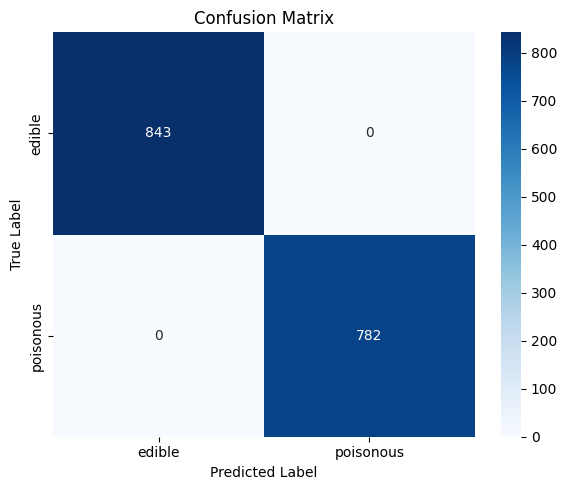

In [10]:
# Figure 1: Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["edible", "poisonous"],
            yticklabels=["edible", "poisonous"], ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

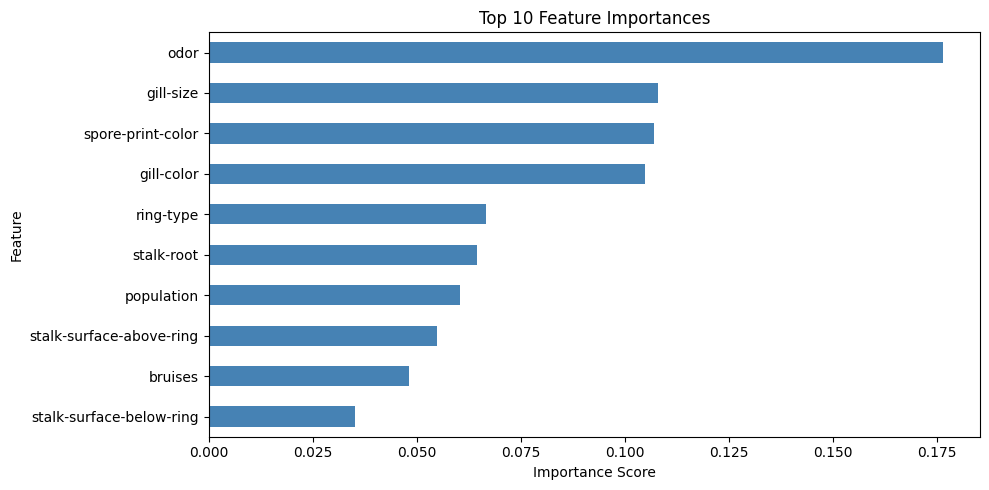

In [11]:
# Figure 2: Top 10 Feature Importances
importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
top_features.plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("Top 10 Feature Importances")
ax.set_xlabel("Importance Score")
ax.set_ylabel("Feature")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Summary

This project built a Random Forest classifier to predict whether a mushroom is edible or poisonous based on 22 physical characteristics. The model achieved 100% accuracy on the test set, with perfect precision and recall for both classes. While this result is technically correct, it reflects the nature of the dataset rather than exceptional modeling — the mushroom dataset is well-known in the ML community for being nearly perfectly separable, with features like `odor` alone being highly predictive of class. This means the dataset is effective for demonstrating a complete ML workflow but should not be taken as evidence that the model would generalize to real-world mushroom identification, where features are continuous, noisy, and harder to measure. A key takeaway is that model evaluation must always be interpreted in the context of the data — perfect metrics can indicate an easy problem just as readily as a good model.